In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('data/stud.csv')
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race_ethnicity               1000 non-null   str  
 2   parental_level_of_education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test_preparation_course      1000 non-null   str  
 5   math_score                   1000 non-null   int64
 6   reading_score                1000 non-null   int64
 7   writing_score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


#### No null values and five categorical features are there and three numerical features.

In [4]:
df.duplicated().sum()

np.int64(0)

#### there is no duplicate records.

In [5]:
df.nunique()

gender                          2
race_ethnicity                  5
parental_level_of_education     6
lunch                           2
test_preparation_course         2
math_score                     81
reading_score                  72
writing_score                  77
dtype: int64

In [6]:
num_columns = df.select_dtypes(exclude=["str"]).columns
cat_feature = df.select_dtypes(include=["str"]).columns
num_columns,cat_feature

(Index(['math_score', 'reading_score', 'writing_score'], dtype='str'),
 Index(['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch',
        'test_preparation_course'],
       dtype='str'))

In [7]:
for col in cat_feature:
    print("unique values in {} are: {}".format(col,df[col].unique().tolist()))

unique values in gender are: ['female', 'male']
unique values in race_ethnicity are: ['group B', 'group C', 'group A', 'group D', 'group E']
unique values in parental_level_of_education are: ["bachelor's degree", 'some college', "master's degree", "associate's degree", 'high school', 'some high school']
unique values in lunch are: ['standard', 'free/reduced']
unique values in test_preparation_course are: ['none', 'completed']


In [8]:
df['total_score'] = df["math_score"] + df['reading_score'] + df['writing_score']
df['average'] = df['total_score']/3

# 4.Exploring data (visualization)

### 4.1 Visualize average score distribution to make some conclusion

#### 4.1.1 Histogram & KDE

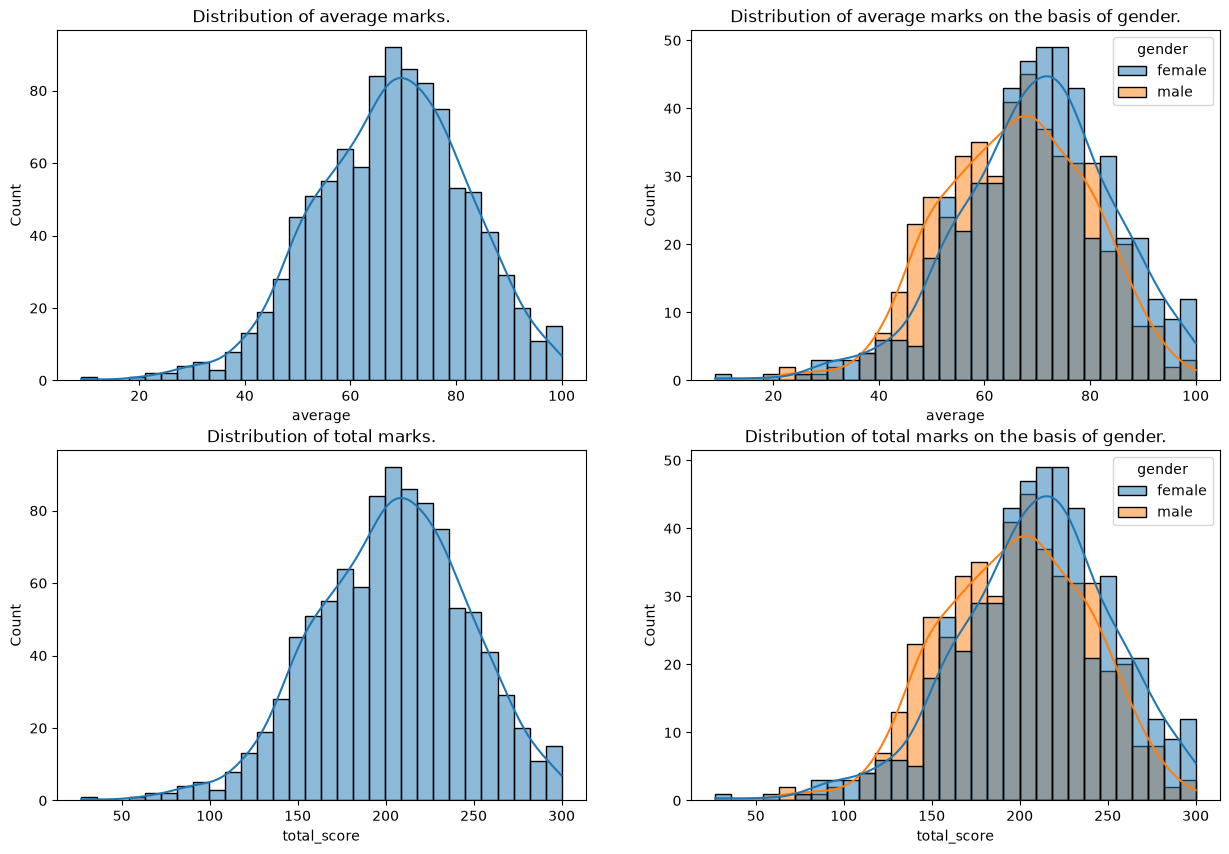

In [9]:
fig, axs = plt.subplots(2,2,figsize=(15,10))
plt.subplot(221)
sns.histplot(df,x='average',bins=30,kde=True,)
plt.title('Distribution of average marks.')
plt.subplot(222)
sns.histplot(df,x='average',bins=30,kde=True,hue='gender')
plt.title('Distribution of average marks on the basis of gender.')
plt.subplot(223)
sns.histplot(df,x='total_score',bins=30,kde=True,)
plt.title('Distribution of total marks.')
plt.subplot(224)
sns.histplot(df,x='total_score',bins=30,kde=True,hue='gender')
plt.title('Distribution of total marks on the basis of gender.')
plt.show()

##### Insights
- Female student perform more than the male students.

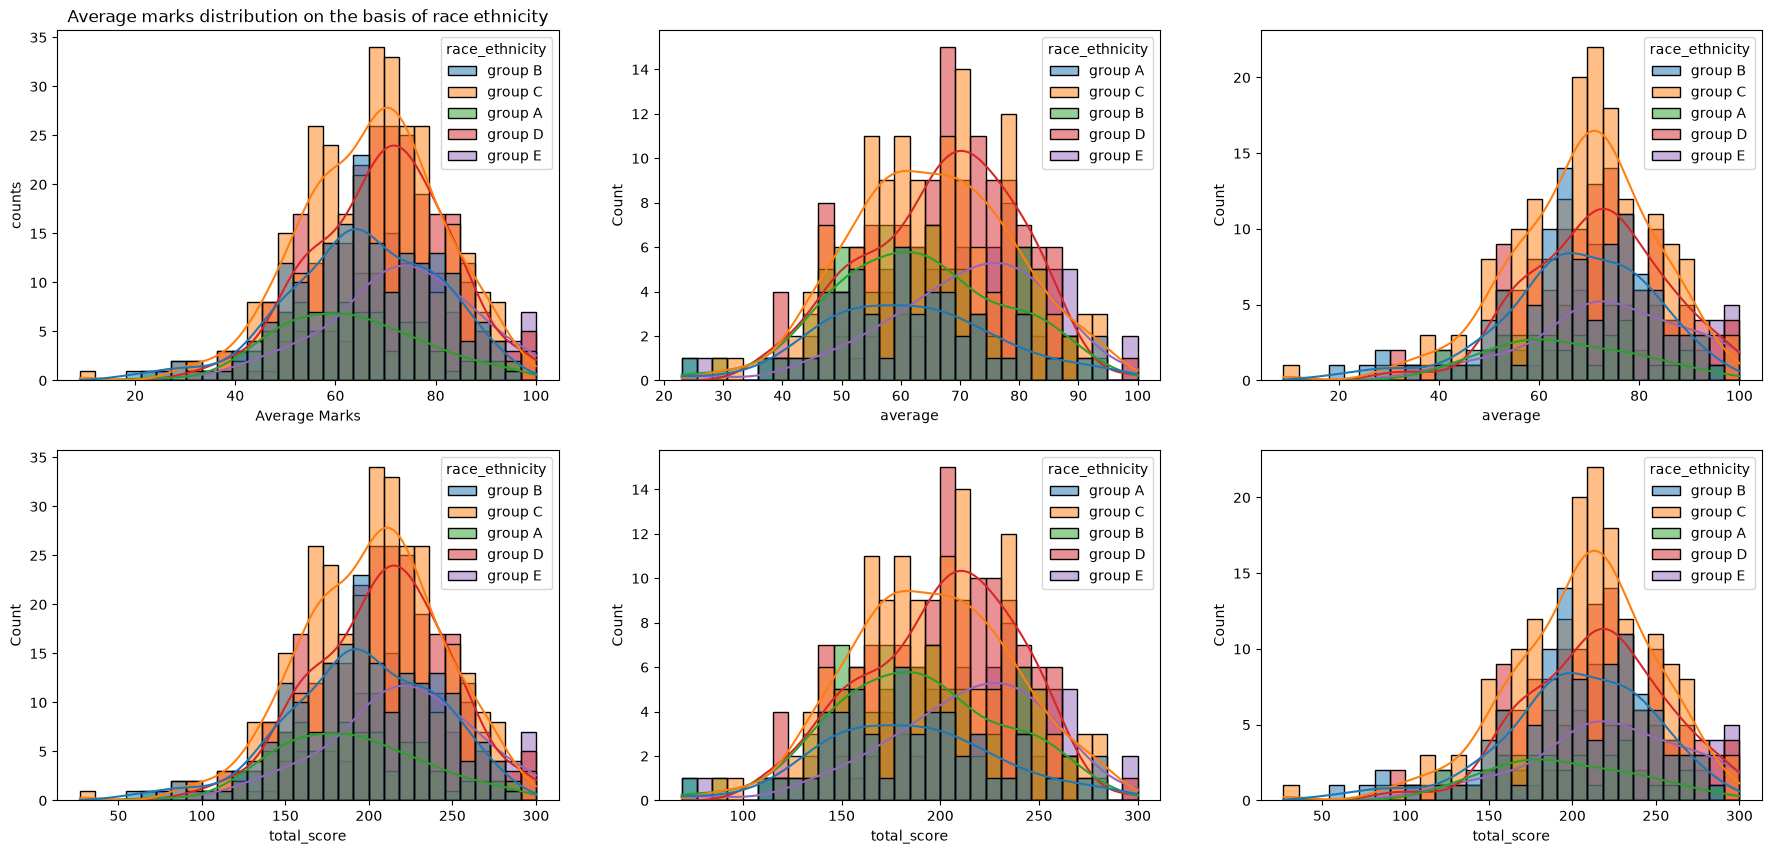

In [10]:
f,ax=plt.subplots(2,3,figsize=(22,10))
sns.histplot(df,x='average',bins=30,ax=ax[0][0],kde=True,hue='race_ethnicity')
ax[0,0].set(xlabel='Average Marks',ylabel='counts',title='Average marks distribution on the basis of race ethnicity')
sns.histplot(df[df['gender']=='male'],x='average',bins=30,ax=ax[0][1],kde=True,hue='race_ethnicity')
sns.histplot(df[df['gender']=='female'],x='average',bins=30,ax=ax[0][2],kde=True,hue='race_ethnicity')
sns.histplot(df,x='total_score',bins=30,ax=ax[1][0],kde=True,hue='race_ethnicity')
sns.histplot(df[df['gender']=='male'],x='total_score',bins=30,ax=ax[1][1],kde=True,hue='race_ethnicity')
sns.histplot(df[df['gender']=='female'],x='total_score',bins=30,ax=ax[1][2],kde=True,hue='race_ethnicity')
plt.show()

#### Insights
- In general the people of race group A has the lowest performance and group C has highest performance.
- The performance order is C > D > B > E > A
- The performance order in males -
  - D ~ C > B ~ E > A
- The performance order in females -
  - C > D > B > E > A

### 4.2 maximum score of students in all three subjects

Text(0.5, 1.0, 'Writing Score')

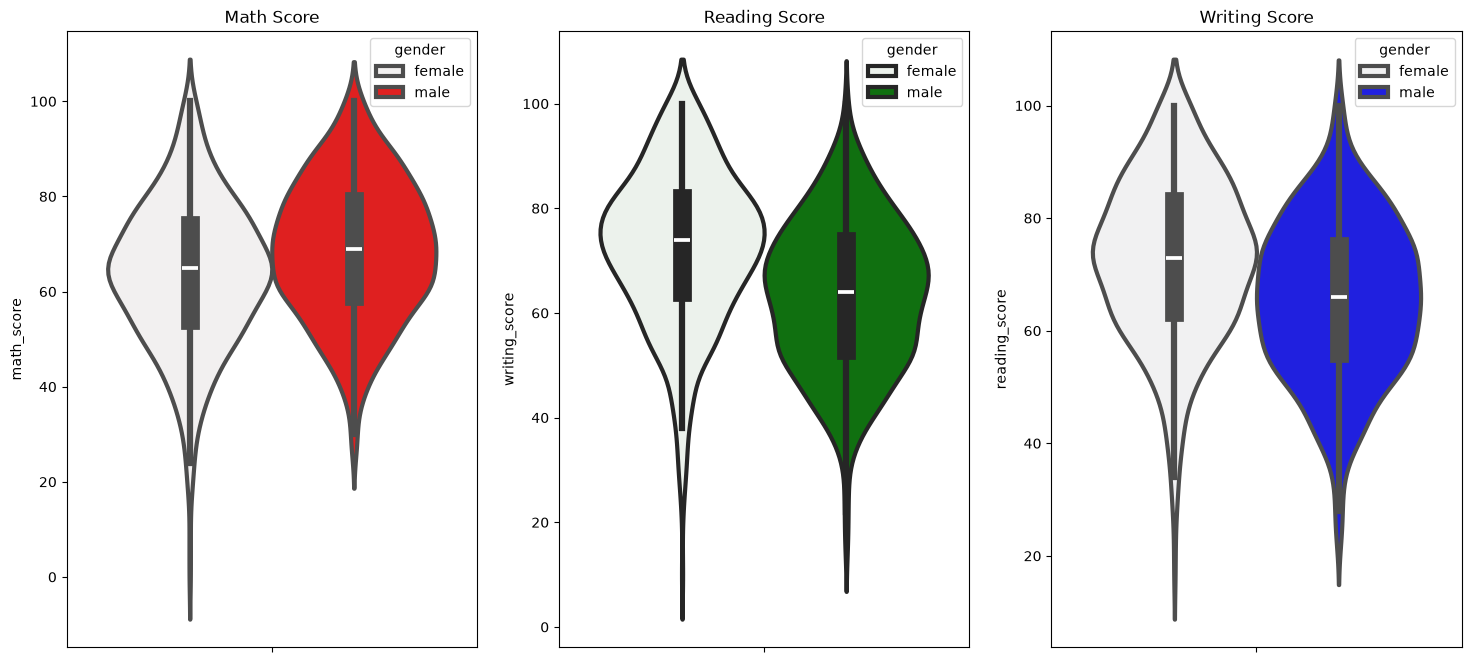

In [11]:
f,ax = plt.subplots(1,3,figsize=(18,8))
sns.violinplot(data=df,y='math_score',palette='light:r',linewidth=3,ax=ax[0],hue='gender')
ax[0].set_title('Math Score')
sns.violinplot(data=df,y='writing_score',palette='light:g',linewidth=3,ax=ax[1],hue='gender')
ax[1].set_title('Reading Score')
sns.violinplot(data=df,y='reading_score',palette='light:b',linewidth=3,ax=ax[2],hue='gender')
ax[2].set_title('Writing Score')

##### Insights
- In maths the score of males is slightly high.
- In reading and writing the score of females is high.
- The score is mostly in the range of 50-80.

### 4.3 Multivariate analysis using pieplot

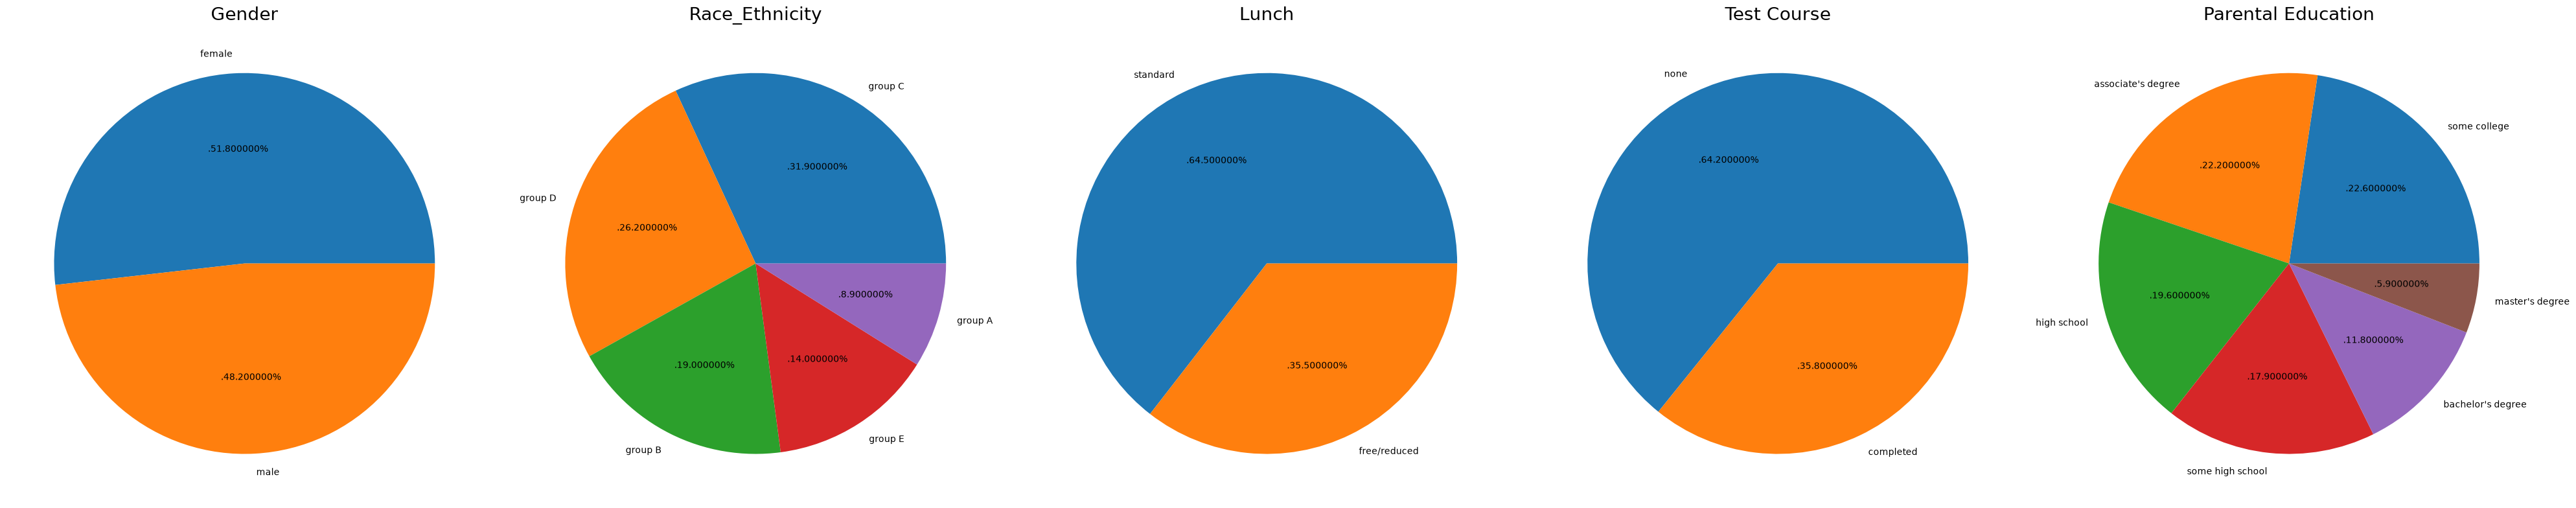

In [12]:
plt.figure(figsize= (40, 15))

plt.subplot(1, 5, 1)
size = df['gender'].value_counts()
plt.pie(size,  labels = list(size.keys()),autopct = '.%2f%%')
plt.title('Gender', fontsize = 20)
plt.axis('off')


plt.subplot(1, 5, 2)
size = df['race_ethnicity'].value_counts()

plt.pie(size, labels = list(size.keys()),autopct = '.%2f%%')
plt.title('Race_Ethnicity', fontsize = 20)
plt.axis('off')



plt.subplot(1, 5, 3)
size = df['lunch'].value_counts()

plt.pie(size, labels = list(size.keys()),autopct = '.%2f%%')
plt.title('Lunch', fontsize = 20)
plt.axis('off')


plt.subplot(1, 5, 4)
size = df['test_preparation_course'].value_counts()

plt.pie(size, labels = list(size.keys()),autopct = '.%2f%%')
plt.title('Test Course', fontsize = 20)
plt.axis('off')


plt.subplot(1, 5, 5)
size = df['parental_level_of_education'].value_counts()

plt.pie(size, labels = list(size.keys()),autopct = '.%2f%%')
plt.title('Parental Education', fontsize = 20)
plt.axis('off')


plt.tight_layout()
plt.grid()

plt.show()

#####  Insights
- Number of Male and Female students is almost equal
- Number students are greatest in Group C
- Number of students who have standard lunch are greater
- Number of students who have not enrolled in any test preparation course is greater
- Number of students whose parental education is "Some College" is greater followed closely by "Associate's Degree"

#### 4.4 Feature Wise Visualization
#### 4.4.1 GENDER COLUMN
- How is distribution of Gender ?
- Is gender has any impact on student's performance ?

#### UNIVARIATE ANALYSIS ( How is distribution of Gender ? )

/tmp/ipykernel_45875/1720327845.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['gender'],data=df,palette ='bright',ax=ax[0],saturation=0.95)


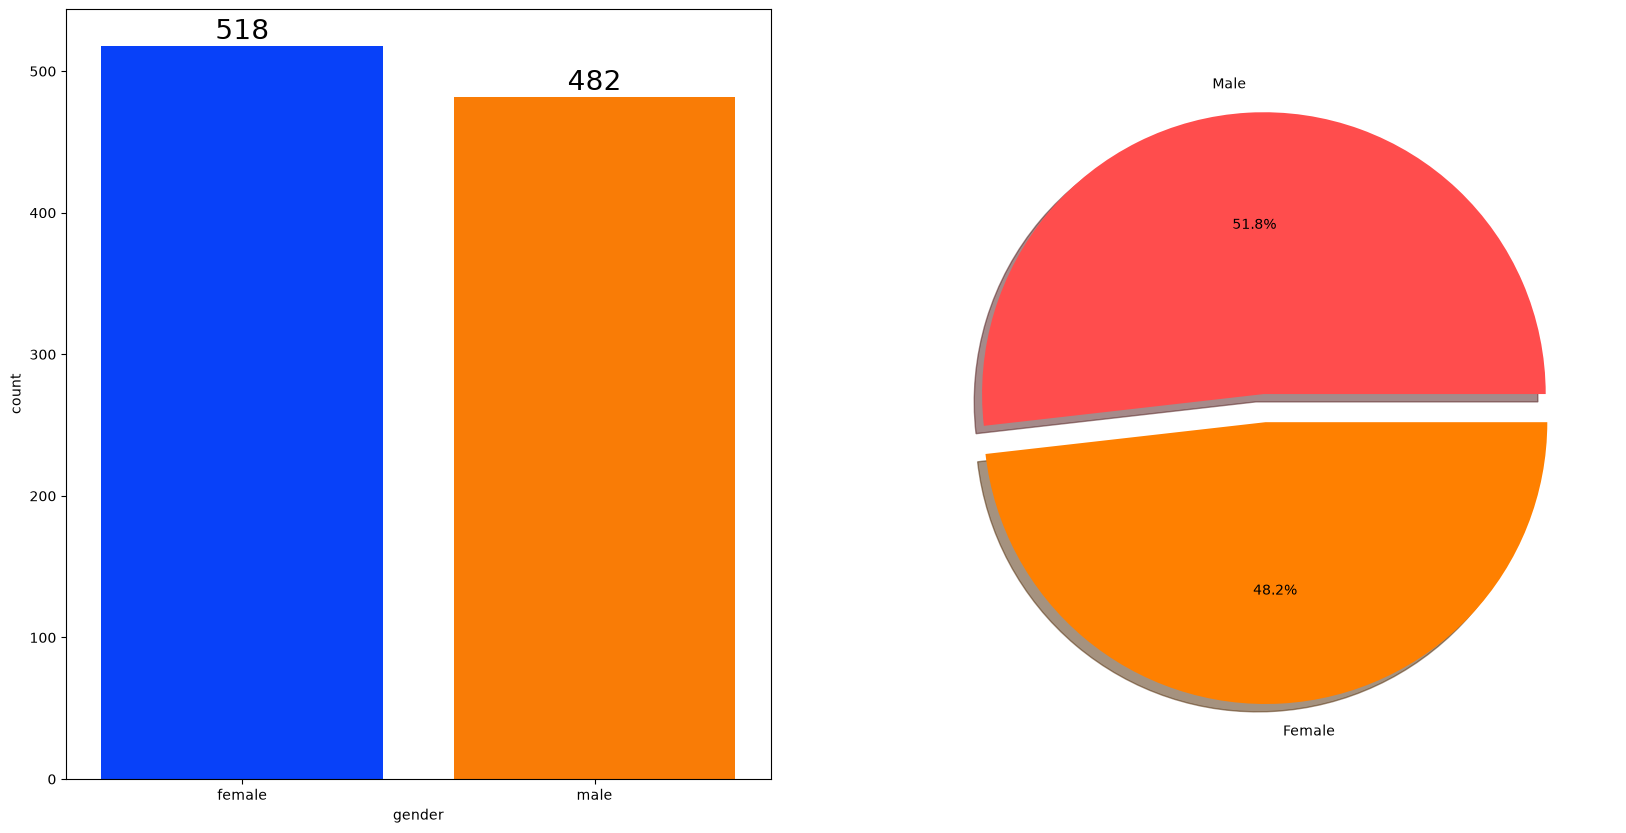

In [13]:
f,ax=plt.subplots(1,2,figsize=(20,10))
sns.countplot(x=df['gender'],data=df,palette ='bright',ax=ax[0],saturation=0.95)
for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=20)
    
plt.pie(x=df['gender'].value_counts(),labels=['Male','Female'],explode=[0,0.1],autopct='%1.1f%%',shadow=True,colors=['#ff4d4d','#ff8000'])
plt.show()

#### Insights 
- Gender has balanced data with female students are 518 (48%) and male students are 482 (52%) 

#### BIVARIATE ANALYSIS ( Is gender has any impact on student's performance ? ) 

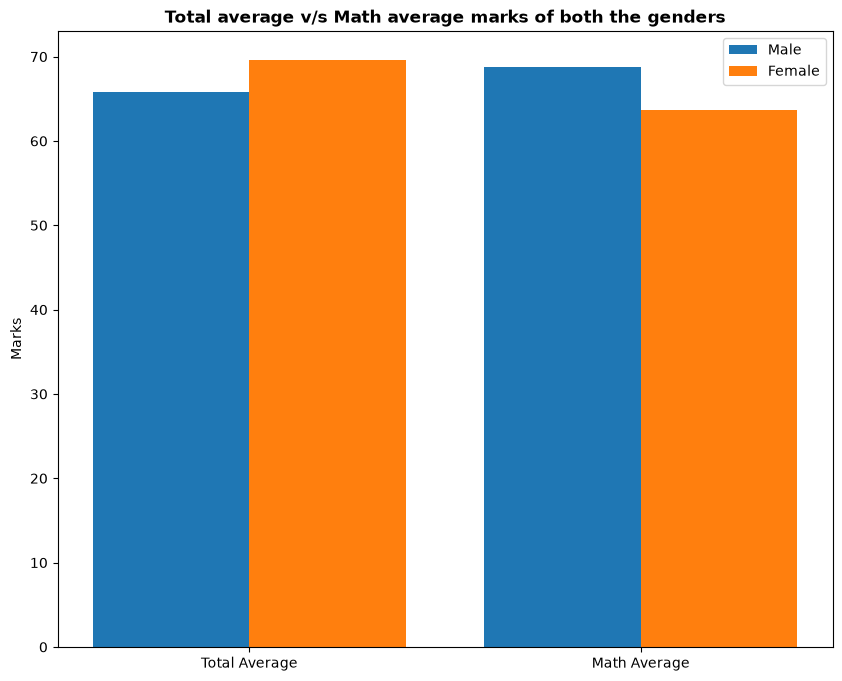

In [14]:
gender_group = df.groupby('gender')

plt.figure(figsize=(10, 8))

X = ['Total Average','Math Average']


female_scores = [gender_group['average'].mean()['female'], gender_group['math_score'].mean()['female']]
male_scores = [gender_group['average'].mean()['male'], gender_group['math_score'].mean()['male']]

X_axis = np.arange(len(X))
  
plt.bar(X_axis - 0.2, male_scores, 0.4, label = 'Male')
plt.bar(X_axis + 0.2, female_scores, 0.4, label = 'Female')
  
plt.xticks(X_axis, X)
plt.ylabel("Marks")
plt.title("Total average v/s Math average marks of both the genders", fontweight='bold')
plt.legend()
plt.show()

#### Insights 
- On an average females have a better overall score than men.
- whereas males have scored higher in Maths.

#### 4.4.6 CHECKING OUTLIERS

<Axes: >

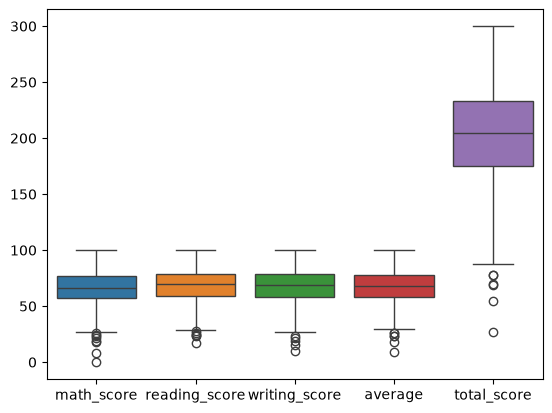

In [15]:
sns.boxplot(df[['math_score','reading_score','writing_score','average','total_score','gender']])

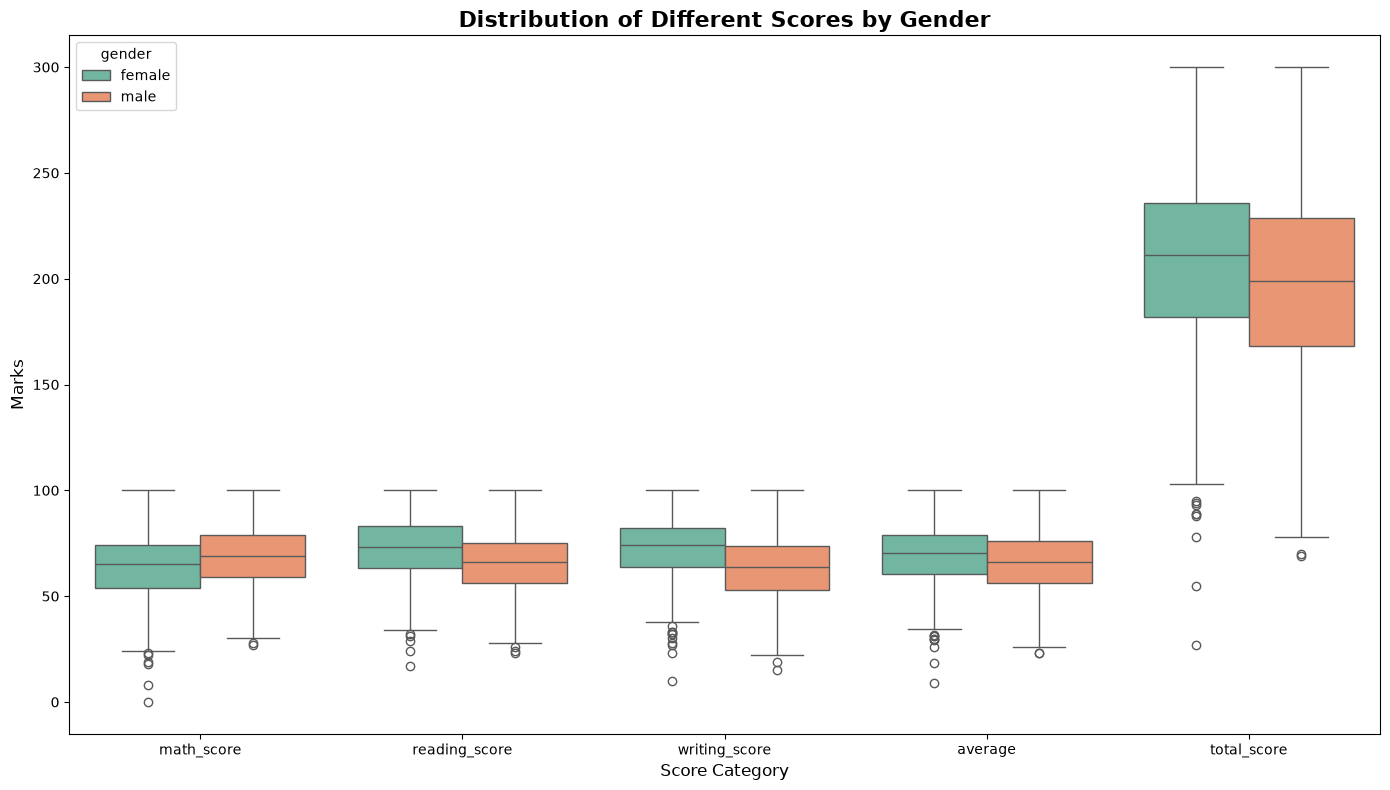

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Melt the dataframe to convert it from wide format to long format
df_melted = df.melt(
    id_vars=['gender'], 
    value_vars=['math_score', 'reading_score', 'writing_score', 'average', 'total_score'],
    var_name='Score_Type', 
    value_name='Marks'
)

# 2. Plot using 'Score_Type' on X, 'Marks' on Y, and 'gender' as the hue
plt.figure(figsize=(14, 8))
sns.boxplot(data=df_melted, x='Score_Type', y='Marks', hue='gender', palette='Set2')

plt.title("Distribution of Different Scores by Gender", fontsize=16, fontweight='bold')
plt.xlabel("Score Category", fontsize=12)
plt.ylabel("Marks", fontsize=12)
plt.tight_layout()
plt.show()


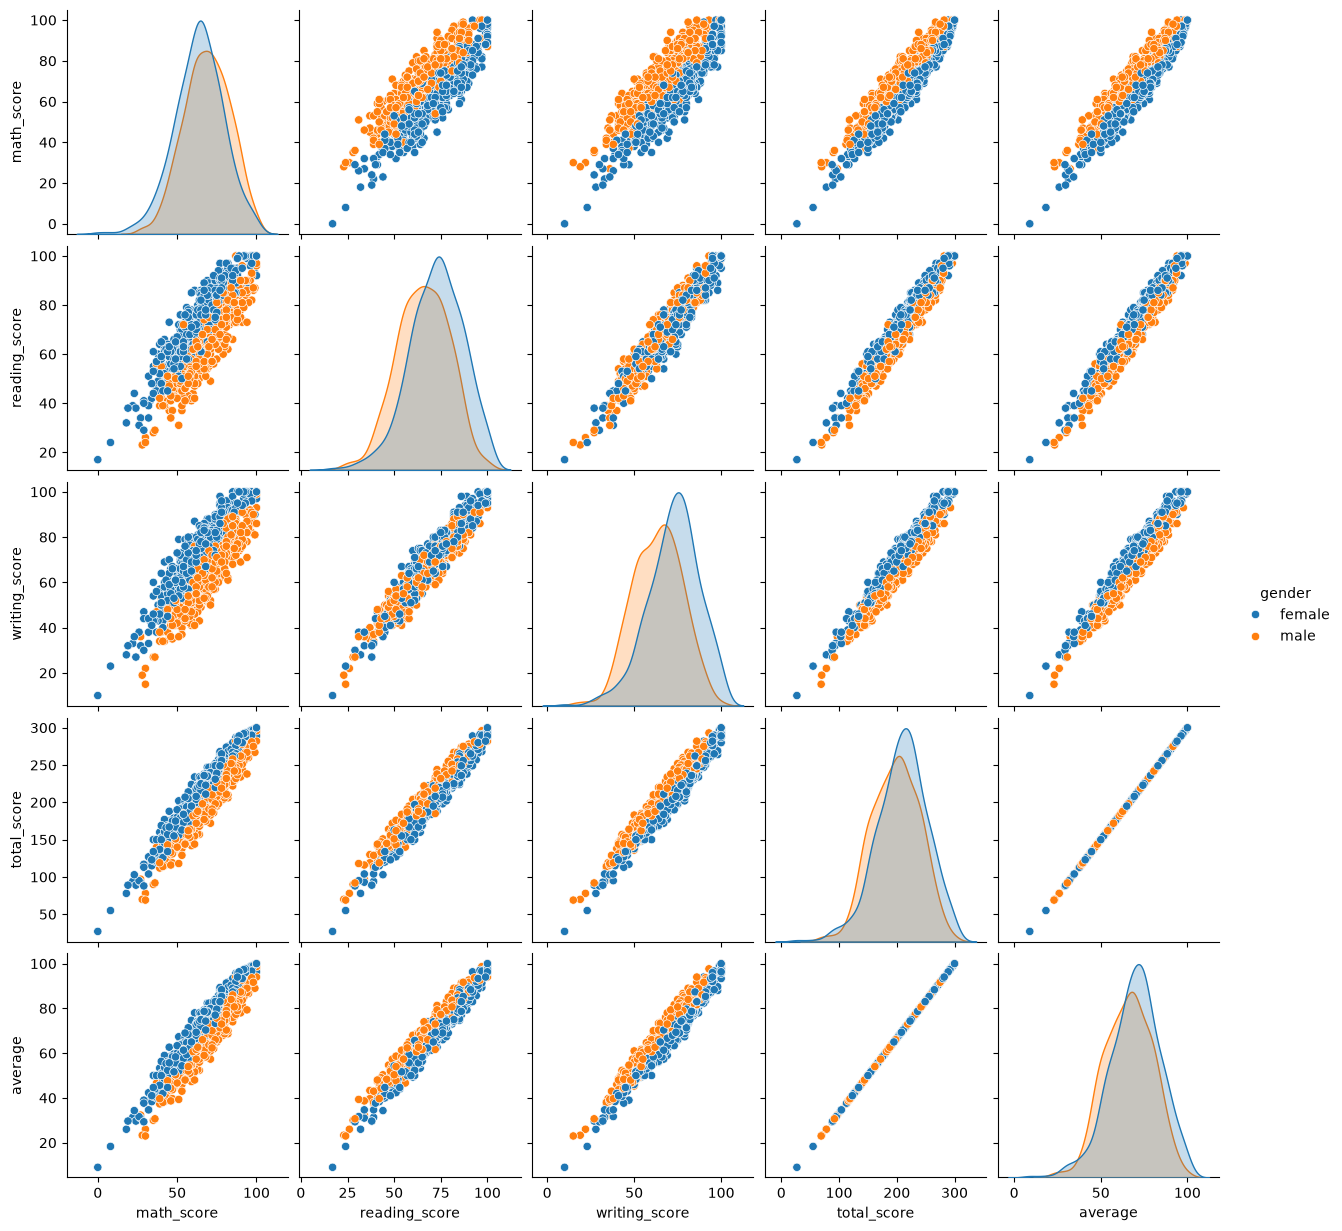

In [17]:
sns.pairplot(df,hue = 'gender')
plt.show()

#### Insights
- From the above plot it is clear that all the scores increase linearly with each other.

### 5. Conclusions
- Student's Performance is related with lunch, race, parental level education
- Females lead in pass percentage and also are top-scorers
- Student's Performance is not much related with test preparation course
- Finishing preparation course is benefitial.